<a href="https://colab.research.google.com/github/Maryam-Taherzadeh/Computational-Drug-Discovery/blob/main/notebooks/mdm2_pIC50_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 🤖 Part 4: Regression Modeling with Random Forest (MDM2 Inhibitors)

**Author: Maryam Taherzadeh**

In this section, a machine learning model is developed to predict the bioactivity (**pIC50**) of small molecules targeting the **MDM2–p53 interaction**, a key protein-protein interaction in cancer biology.

This step follows the computational drug discovery pipeline and focuses on learning the relationship between molecular structure and biological activity.

---

### 🎯 Objective

- Train a regression model to predict **pIC50**
- Use molecular descriptors and fingerprints as input features
- Evaluate model performance on unseen data

---

### 🧠 Model Choice: Random Forest

The **Random Forest Regressor** is selected as a baseline model due to its strong performance in QSAR tasks:

- ✔ Handles high-dimensional molecular data (descriptors + fingerprints)
- ✔ Captures non-linear relationships between structure and activity
- ✔ Robust to noise and overfitting through ensemble learning
- ✔ Provides feature importance for interpretability

---

### ⚙️ Input Data

- **X (features):**
  - PaDEL molecular descriptors  
  - PubChem fingerprint vectors  

- **y (target):**
  - Experimental **pIC50 values**

---

### 🔬 Workflow

1. Split dataset into training (80%) and test (20%) sets  
2. Train Random Forest regression model  
3. Perform hyperparameter tuning using **RandomizedSearchCV** with cross-validation  
4. Predict pIC50 values on the test set  
5. Evaluate performance using multiple metrics  

---

### 📊 Evaluation Metrics

- **R² (Coefficient of Determination):**
  - Measures proportion of variance explained by the model  
  - Higher values indicate better predictive performance  

- **MSE (Mean Squared Error):**
  - Penalizes large prediction errors  
  - Lower values indicate better performance  

- **MAE (Mean Absolute Error):**
  - Represents average prediction error  
  - Easier to interpret in pIC50 units  

---

### 📈 Results Summary

- **Baseline Random Forest:** R² ≈ 0.63  
- **Tuned Random Forest (RandomizedSearchCV):** R² ≈ 0.65  

Hyperparameter optimization improved model performance, particularly by reducing larger prediction errors, while maintaining stable average prediction accuracy.

---

### 🚀 Significance

This modeling step demonstrates how machine learning can:

- Predict compound potency from molecular structure  
- Reduce reliance on costly wet-lab experiments  
- Accelerate early-stage drug discovery workflows  

---

### 🔜 Next Steps

- Compare performance with advanced models (e.g., XGBoost, Support Vector Regression)  
- Apply cross-validation for more robust evaluation  
- Explore improved molecular representations (e.g., graph-based models)  
- Deploy the final model in a user-friendly application (e.g., Streamlit)

## **1. Import libraries**

In [252]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

## **2. Load the data set**

In [253]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/mdm2_07_padel_descriptors_pIC50.csv')
df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(5792, 882)

## **3. Input features**
The MDM2 dataset contains 881 molecular descriptors generated using PaDEL. These descriptors numerically represent the chemical structure of each compound and are used as input features for machine learning.

The output variable is pIC50, which quantifies the inhibitory activity of compounds against the MDM2 target. Lower IC50 values (and thus higher pIC50 values) indicate stronger inhibitory activity.

### **3.1. Input features**

In [254]:
X = df.drop('pIC50', axis=1)
X.shape

(5792, 881)

### **3.2. Output features**

In [255]:
Y = df.pIC50
Y

,pIC50
0,5.769551
1,6.698970
2,4.522879
3,4.886057
4,5.443697
...,...
5787,9.619789
5788,9.161151
5789,8.543634
5790,9.602060


### **3.3. Let's examine the data dimension**

In [256]:
X.shape

(5792, 881)

In [257]:
Y.shape

(5792,)

### **3.4. Remove low variance features**




In [258]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# Step 1: define threshold
threshold = 0.8 * (1 - 0.8)  # = 0.16

# Step 2: apply selection
selection = VarianceThreshold(threshold=threshold)

X_var = selection.fit_transform(X)

# Step 3: keep column names
selected_columns = X.columns[selection.get_support()]

X = pd.DataFrame(X_var, columns=selected_columns)

print("Remaining features:", X.shape[1])

Remaining features: 192


In [259]:
X.shape

(5792, 192)

## **4. Data split (80/20 ratio)**

In [260]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

In [261]:
X_train.shape, y_train.shape

((4633, 192), (4633,))

In [262]:
X_test.shape, y_test.shape

((1159, 192), (1159,))

## **5. Building a Regression Model using Random Forest(Baseline)**





In [263]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [264]:
y_pred = rf_model.predict(X_test)


## **6. Evaluate Model**

In [265]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R²:", r2)
print("MSE:", mse)
print("MAE:", mae)

R²: 0.6269129473533213
MSE: 0.7565529198966845
MAE: 0.626032736869564


## **7. Scatter Plot of Experimental vs Predicted pIC50 Values**

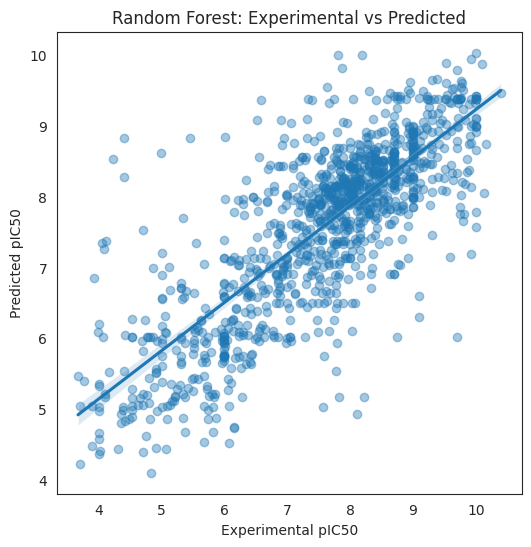

In [266]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_style("white")

plt.figure(figsize=(6,6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4})

plt.xlabel('Experimental pIC50')
plt.ylabel('Predicted pIC50')
plt.title('Random Forest: Experimental vs Predicted')

plt.show()

## **8. Feature importance**
Note: It measures how much each feature contributes to reducing prediction error in the model. In Random Forest, it is based on how much each feature decreases impurity across trees.

Note: Do feature selection AFTER split to avoid data leakage:


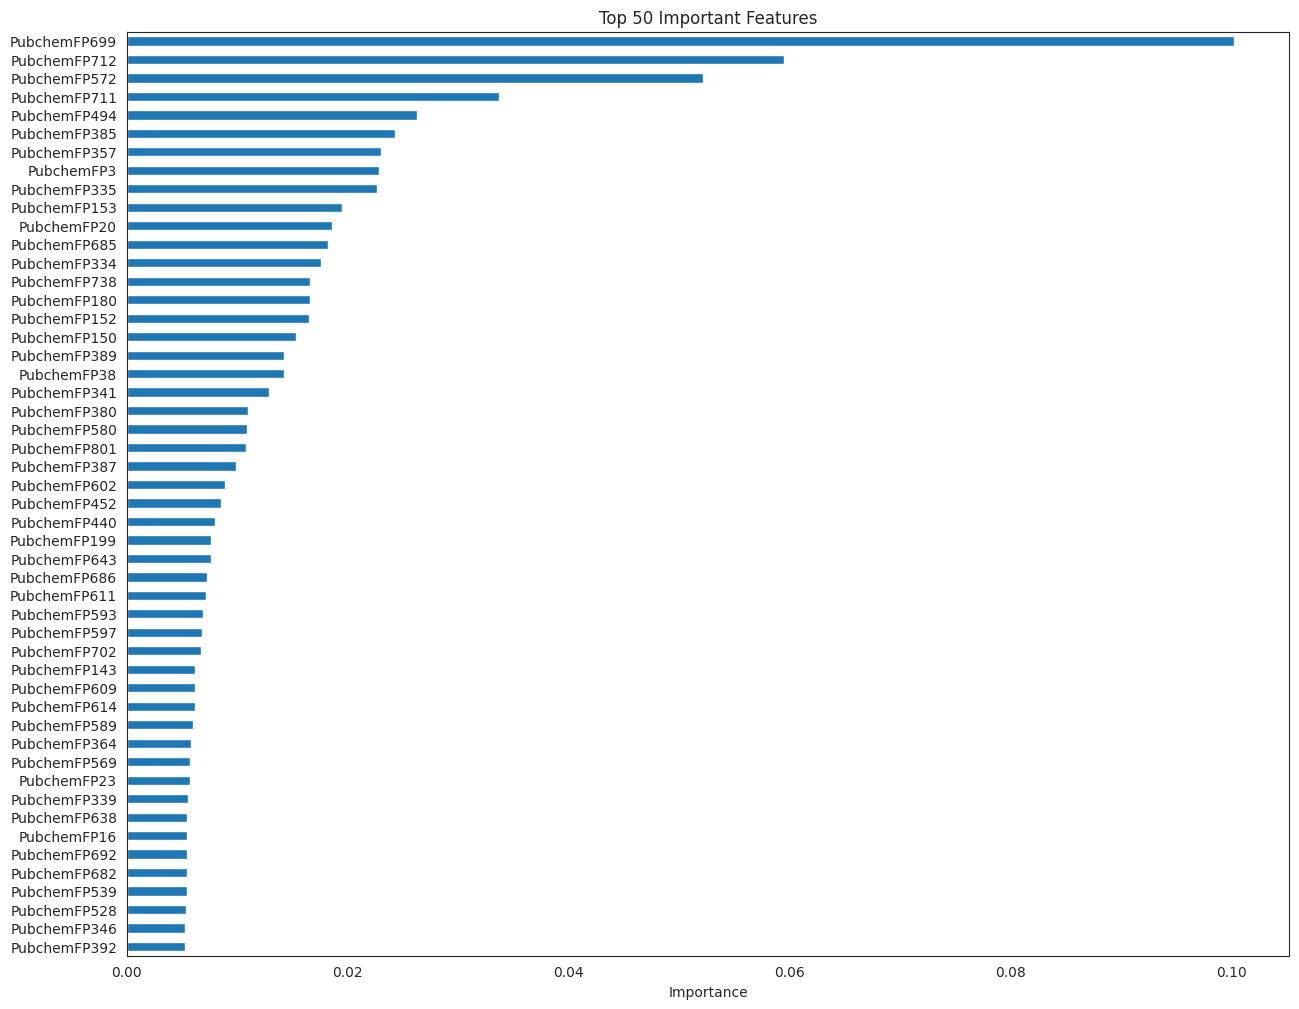

In [267]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_importance = pd.Series(importances, index=feature_names)

# Select top 50 feature names
top_features = feat_importance.nlargest(50).index

# Plot
feat_importance.loc[top_features].sort_values().plot(kind='barh', figsize=(15,12))

plt.title('Top 50 Important Features')
plt.xlabel('Importance')
plt.show()



### Interpretation of Feature Importance Plot

This plot shows the top 50 most important PubChem fingerprint features selected by the Random Forest model for predicting pIC50.

The most important feature is **PubchemFP699**, with the highest importance score. This means the model relies on this molecular fingerprint feature more than the others when making predictions.

A few features, such as **PubchemFP712**, **PubchemFP572**, and **PubchemFP711**, also contribute noticeably to the prediction. However, many other features have very small importance values, meaning they have little effect on the model output.

Overall, the plot suggests that only a small number of molecular fingerprint features strongly influence pIC50 prediction, while many features contribute weakly. This is common in molecular fingerprint datasets because many fingerprint bits may be sparse or less relevant to biological activity.

##**✅ Step 1: Keep only important features**







In [268]:
top_features = feat_importance.nlargest(100).index
X = X[top_features]
X.shape

X_train_50 = X_train[top_features]
X_test_50 = X_test[top_features]


##**✅ Step 2: Retrain model with top features**

In [269]:
rf_model_50 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_50.fit(X_train_100, y_train)

y_pred_50= rf_model_50.predict(X_test_100)
len(importances) == len(X_train.columns)


True

##**✅ Step 3: Evaluate again**





In [270]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred_50)
mse = mean_squared_error(y_test, y_pred_50)
mae = mean_absolute_error(y_test, y_pred_50)

print("R²:", r2)
print("MSE:", mse)
print("MAE:", mae)

R²: 0.6277083627202094
MSE: 0.754939961703467
MAE: 0.6256081224667585


###Conclusion:

Feature selection using the top 50 important features resulted in a slight improvement in model performance (R² ≈ 0.628) compared to the baseline. This suggests that moderate feature reduction can help remove noise while preserving important information. However, the improvement is minimal, indicating that model performance is more dependent on model configuration than feature dimensionality.

Your performance is still ~0.62 : Feature selection is NOT the main bottleneck


##**9: Hyperparameter tuning (MOST IMPACT)**

In [251]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(200, 800),
    'max_depth': randint(10, 50),
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best R2:", random_search.best_score_)

Best params: {'max_depth': 17, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 321}
Best R2: 0.6629137063553083


##**Now evaluate on test set**

In [271]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Test R²:", r2_score(y_test, y_pred_best))
print("Test MSE:", mean_squared_error(y_test, y_pred_best))
print("Test MAE:", mean_absolute_error(y_test, y_pred_best))

Test R²: 0.649263482214726
Test MSE: 0.7112300862826704
Test MAE: 0.62663928658035


###Conclusion:

Hyperparameter tuning improved model performance, especially in reducing larger prediction errors, while average error remained relatively stable.